In [28]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

import segmentation_models_pytorch as smp

from skimage.morphology import skeletonize
import networkx as nx

In [29]:
files = os.listdir("train")

sat_ids = {
    f.replace("_sat.jpg", "")
    for f in files
    if f.endswith("_sat.jpg")
}

mask_ids = {
    f.replace("_mask.png", "")
    for f in files
    if f.endswith("_mask.png")
}

common_ids = list(sat_ids & mask_ids)

print("Pairs:", len(common_ids))

Pairs: 6226


In [30]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

model = smp.DeepLabV3Plus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

model.load_state_dict(
    torch.load(
        "deeplabv3plus_road.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


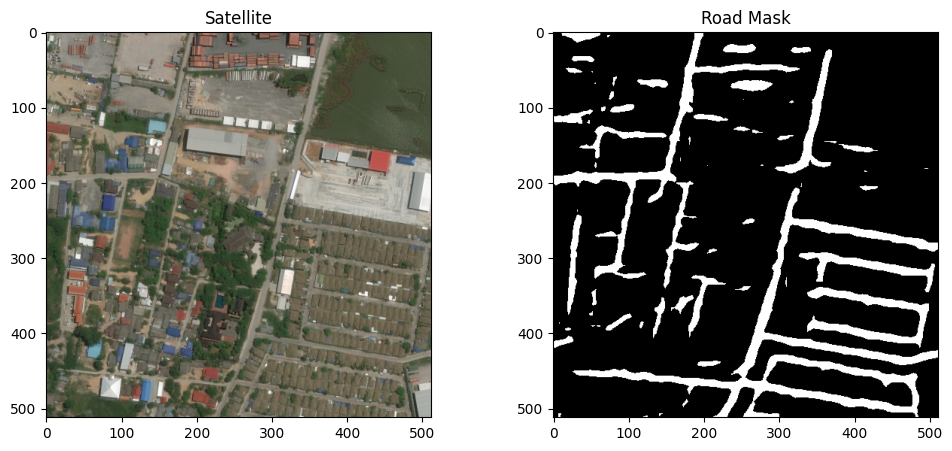

In [31]:
test_id = "227114"

img = cv2.imread(
    f"train/{test_id}_sat.jpg"
)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img_rgb,
    (512,512)
)

x = img_resized.astype(np.float32) / 255.0

x = torch.tensor(
    x.transpose(2,0,1)
).unsqueeze(0)

x = x.to(device)

with torch.no_grad():
    pred = model(x)

pred = torch.sigmoid(pred)

pred = pred.squeeze().cpu().numpy()

pred_binary = (
    pred > 0.2
).astype(np.uint8)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Satellite")

plt.subplot(1,2,2)
plt.imshow(pred_binary, cmap="gray")
plt.title("Road Mask")

plt.show()

In [32]:
test_id = "227114"

img = cv2.imread(f"train/{test_id}_sat.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(
    img_rgb,
    (512,512)
)

x = img_resized.astype(np.float32) / 255.0

x = torch.tensor(
    x.transpose(2,0,1)
).unsqueeze(0)

x = x.to(device)

with torch.no_grad():
    pred = model(x)

pred = torch.sigmoid(pred)
pred = pred.squeeze().cpu().numpy()

pred_binary = (
    pred > 0.5
).astype(np.uint8)

print("Road %:",
      100*np.sum(pred_binary)/pred_binary.size)

print(pred_binary.shape)

Road %: 12.35809326171875
(512, 512)


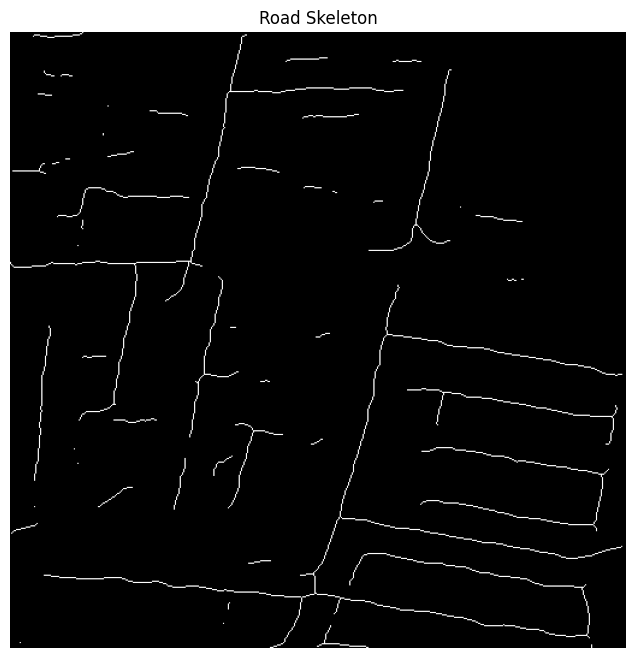

Skeleton Pixels: 4153


In [33]:
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

road_mask = pred_binary.astype(bool)

skeleton = skeletonize(road_mask)

plt.figure(figsize=(8,8))
plt.imshow(skeleton, cmap="gray")
plt.title("Road Skeleton")
plt.axis("off")
plt.show()

print("Skeleton Pixels:", skeleton.sum())

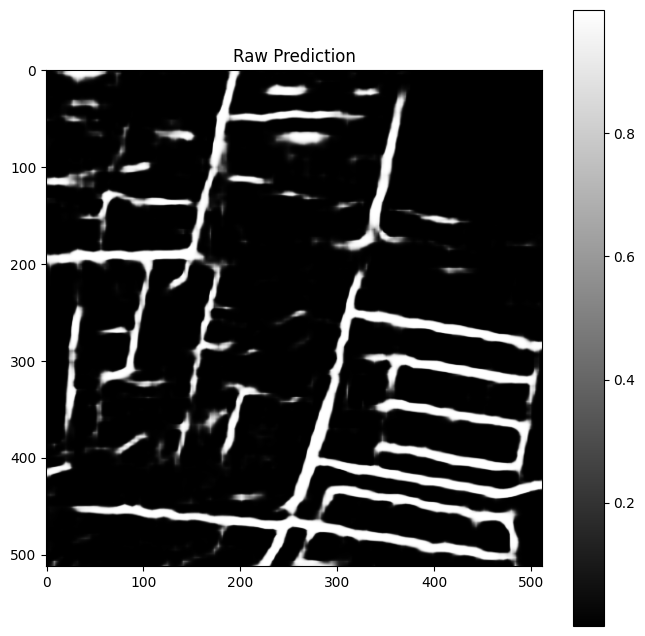

In [34]:
plt.figure(figsize=(8,8))
plt.imshow(pred, cmap="gray")
plt.title("Raw Prediction")
plt.colorbar()
plt.show()

In [35]:
import networkx as nx
import numpy as np

G = nx.Graph()

coords = np.argwhere(skeleton)

for y, x in coords:
    G.add_node((y, x))

coord_set = set(map(tuple, coords))

for y, x in coords:

    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:

            if dy == 0 and dx == 0:
                continue

            ny = y + dy
            nx_ = x + dx

            if (ny, nx_) in coord_set:
                G.add_edge((y, x), (ny, nx_))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Components:", nx.number_connected_components(G))

Nodes: 4153
Edges: 4133
Components: 52


In [48]:
largest_component = max(
    nx.connected_components(G),
    key=len
)

G_main = G.subgraph(
    largest_component
).copy()

junction_nodes = [
    n
    for n in G_main.nodes()
    if G_main.degree(n) >= 3
]

print("Junctions:", len(junction_nodes))

print("Total Nodes:", G.number_of_nodes())
print("Main Nodes :", G_main.number_of_nodes())

Junctions: 22
Total Nodes: 4153
Main Nodes : 1460


In [45]:
bet = nx.betweenness_centrality(
    G_main,
    normalized=True
)

critical_junctions = sorted(
    [
        (n, bet[n])
        for n in junction_nodes
    ],
    key=lambda x: x[1],
    reverse=True
)

print(critical_junctions[:10])

[((402, 274), 0.5744167745538548), ((465, 253), 0.49922387038118254), ((451, 252), 0.49813136569666916), ((449, 252), 0.4967868891916311), ((466, 254), 0.4459619165277531), ((470, 274), 0.43654117905888523), ((470, 275), 0.4294991307912385), ((470, 242), 0.3045154666508714), ((466, 253), 0.30441392576797344), ((501, 478), 0.28597297320166865)]


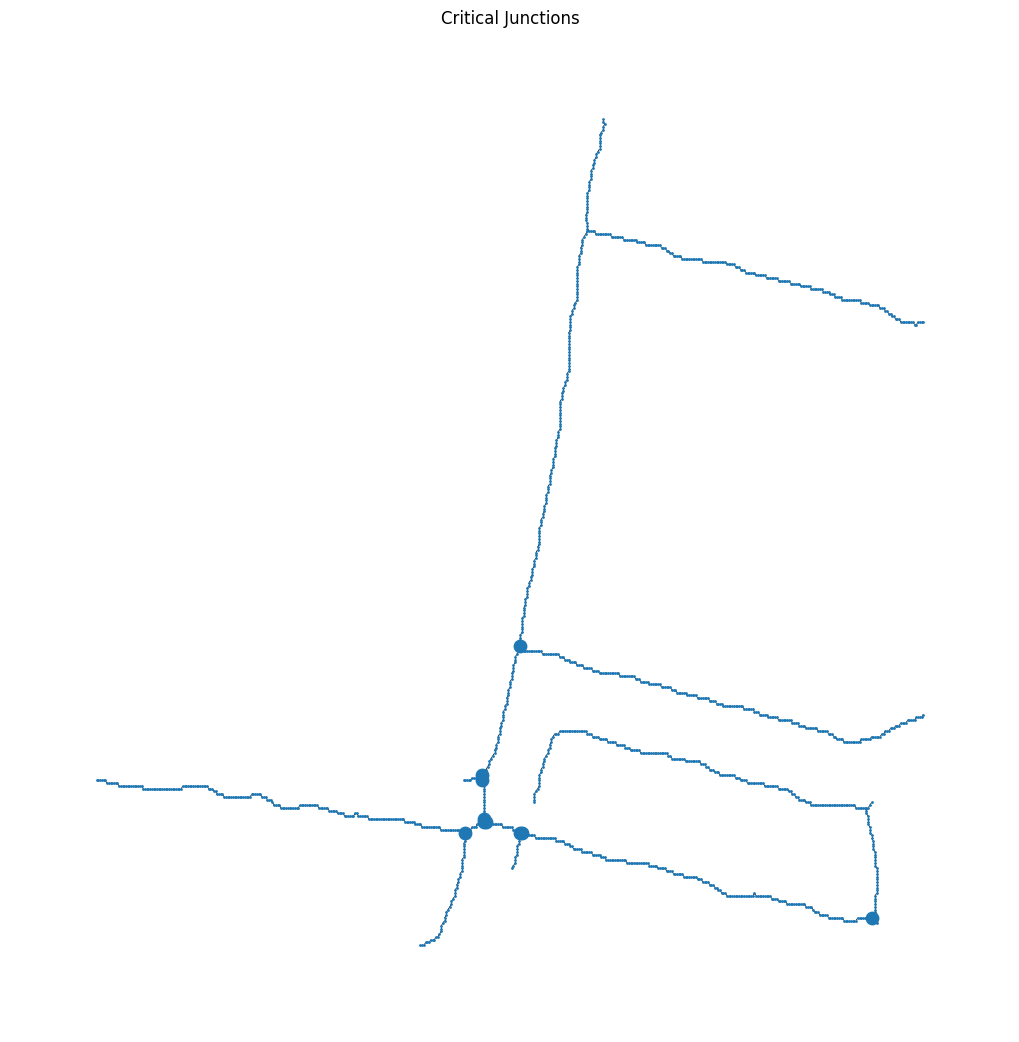

In [46]:
plt.figure(figsize=(10,10))

pos = {
    n:(n[1], -n[0])
    for n in G_main.nodes()
}

nx.draw(
    G_main,
    pos,
    node_size=1,
    width=0.5
)

top_junctions = [
    n for n,_ in critical_junctions[:10]
]

nx.draw_networkx_nodes(
    G_main,
    pos,
    nodelist=top_junctions,
    node_size=80
)

plt.title(
    "Critical Junctions"
)

plt.show()

In [49]:
critical_node = critical_junctions[0][0]

print("Critical Node:", critical_node)

Critical Node: (402, 274)


In [50]:
G_fail = G_main.copy()

before = nx.number_connected_components(G_fail)

G_fail.remove_node(critical_node)

after = nx.number_connected_components(G_fail)

print("Before:", before)
print("After :", after)

Before: 1
After : 3


In [51]:
resilience_score = before / after

print(
    "Resilience Score:",
    resilience_score
)

Resilience Score: 0.3333333333333333


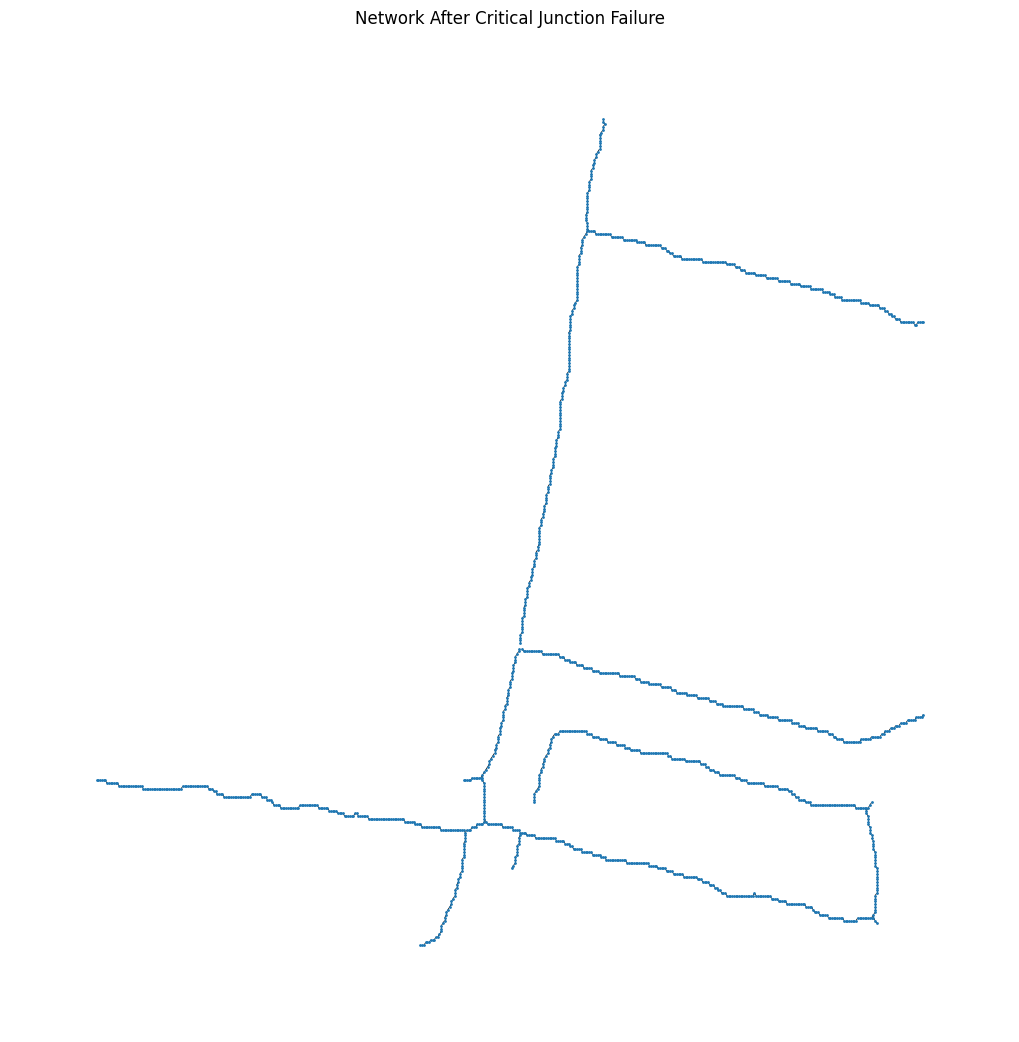

In [52]:
plt.figure(figsize=(10,10))

pos = {
    n:(n[1], -n[0])
    for n in G_fail.nodes()
}

nx.draw(
    G_fail,
    pos,
    node_size=1,
    width=0.5
)

plt.title(
    "Network After Critical Junction Failure"
)

plt.show()